In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(reticulate)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    library(clusterProfiler)
    library(EnhancedVolcano)
    library(org.Hs.eg.db)
    library(GOSemSim)
    library(enrichplot)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [2]:
ascites <- readRDS('/hpc/pmc_stunnenberg/cruiz/scRNA/analysis/pmc_patients/dipg_ascitis/deep_sequencing/for_publication/data/ascites/dmg_ascites_prettx_posttx.rds')
ascites

An object of class Seurat 
43133 features across 19804 samples within 2 assays 
Active assay: SCT (21037 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: mnn, umap

In [ ]:
markers <- FindAllMarkers(
  object = myeloid,
  only.pos = TRUE,          # keep up-regulated genes per cluster
  min.pct = 0.25,           # expressed in ≥25% of cells (tweak as needed)
  logfc.threshold = 0.25,   # effect size filter (tweak as needed)
  test.use = "wilcox"       # default
)

# Pick top 20 markers per cluster by effect size (avg_log2FC in Seurat v5)
top20 <- markers %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = 20, with_ties = FALSE) %>%
  ungroup()

In [20]:
top20

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
3.907287e-228,2.345284,0.288,0.069,8.633541e-224,0,HAMP
0.000000e+00,2.154173,0.978,0.496,0.000000e+00,0,APOC1
0.000000e+00,2.069414,0.995,0.484,0.000000e+00,0,APOE
0.000000e+00,2.016946,0.989,0.498,0.000000e+00,0,C1QB
0.000000e+00,1.982802,0.994,0.542,0.000000e+00,0,C1QA
0.000000e+00,1.958151,0.980,0.468,0.000000e+00,0,C1QC
3.459319e-216,1.936234,0.345,0.108,7.643711e-212,0,CCND1
2.508777e-208,1.799139,0.353,0.115,5.543394e-204,0,LINC01094
2.951735e-242,1.652837,0.383,0.117,6.522153e-238,0,SELENOP


In [6]:
## complement
ego_up <- enrichGO(
  gene          = top20 %>% filter(cluster=='0') %>% pull(gene),
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",
  # universe      = bg_symbols,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

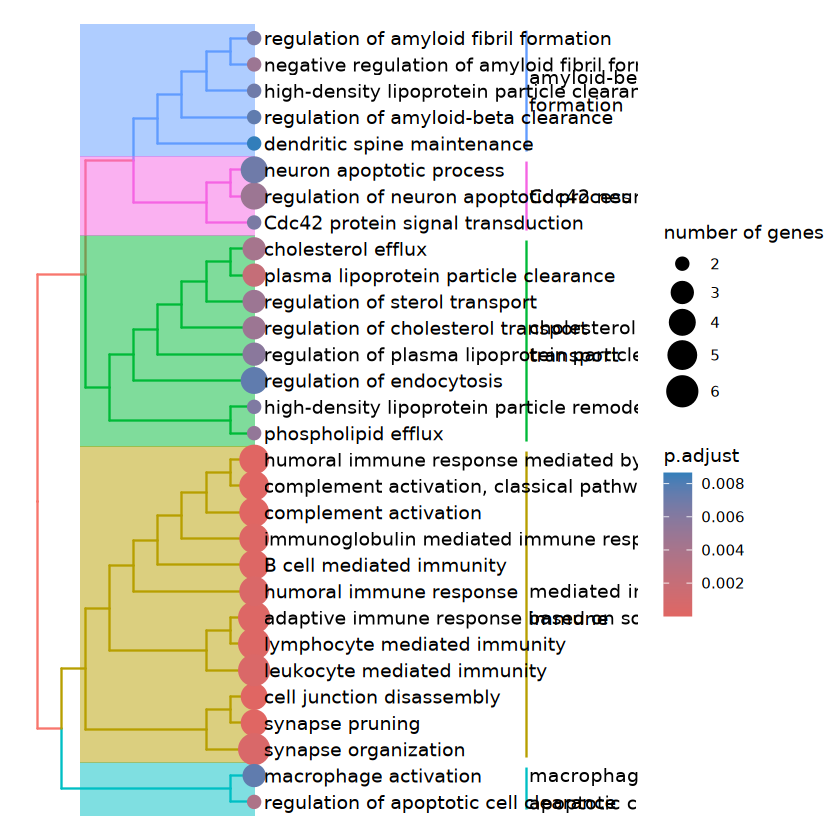

In [10]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego_up, semData = d)
treeplot(ego2)

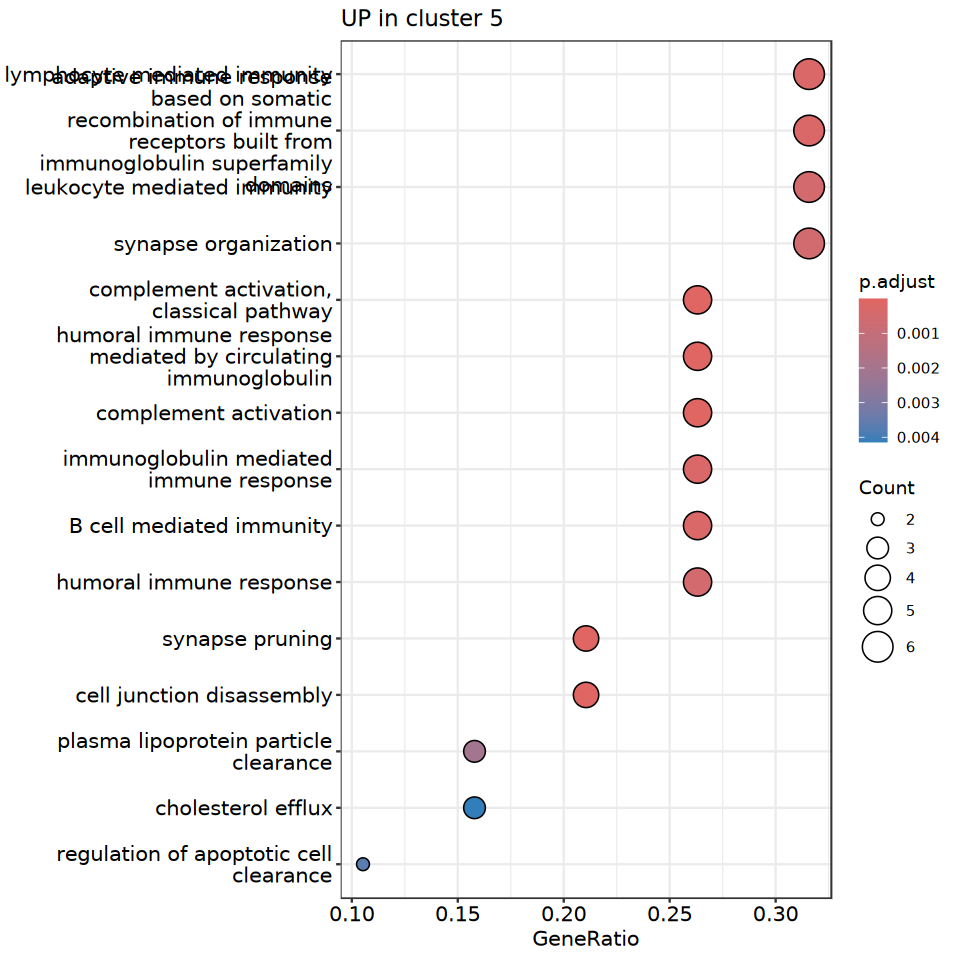

In [24]:
options(repr.plot.height = 8, repr.plot.width = 8)
if (!is.null(ego_up)   && nrow(as.data.frame(ego_up))   > 0) print(dotplot(ego_up,   showCategory = 15, title = "UP in cluster 5"))

Warning message in treeplot.enrichResult(x, ...):
“Use 'cluster.params = list(n = your_value)' instead of 'nCluster'.
 The nCluster parameter will be removed in the next version.”
! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.



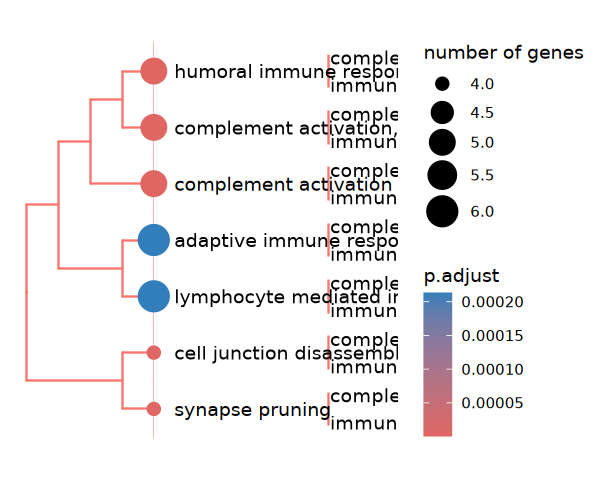

In [12]:
options(repr.plot.height = 4, repr.plot.width = 5)
treeplot(ego2, showCategory = 7, nCluster = 1)

In [13]:
ggsave('figures/go_analysis_cluster_0_myeloid_ascites.pdf', width = 5, height = 4)

In [9]:
## stimulatory-like A
ego_up <- enrichGO(
  gene          = top20 %>% filter(cluster=='1') %>% pull(gene),
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",
  # universe      = bg_symbols,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

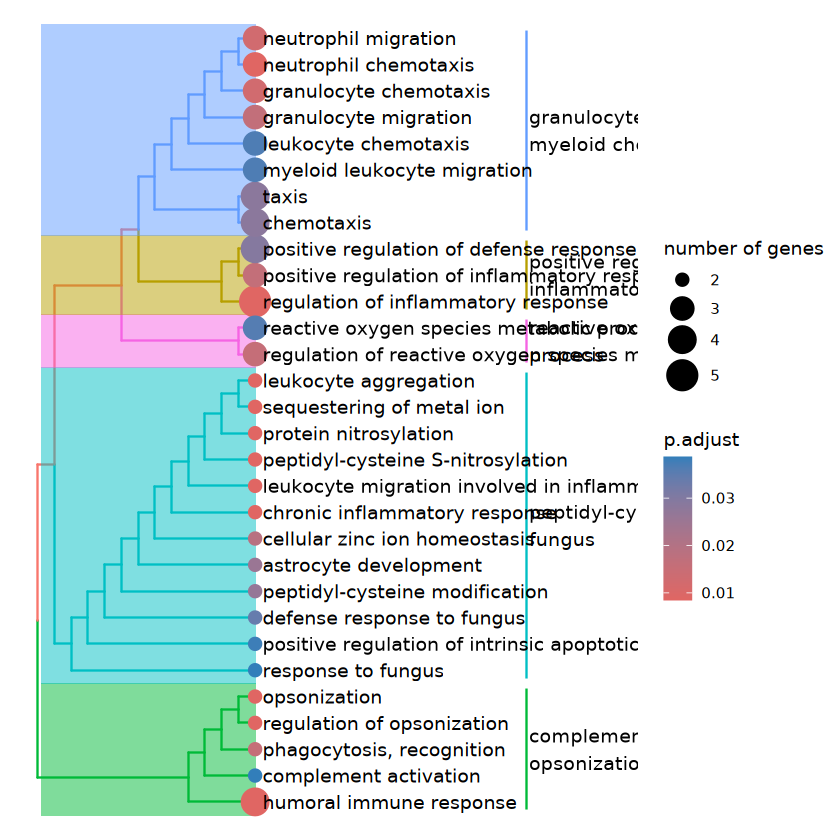

In [10]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego_up, semData = d)
treeplot(ego2)

In [16]:
## stimulatory-like B
ego_up <- enrichGO(
  gene          = top20 %>% filter(cluster=='5') %>% pull(gene),
  OrgDb         = org.Hs.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",
  # universe      = bg_symbols,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

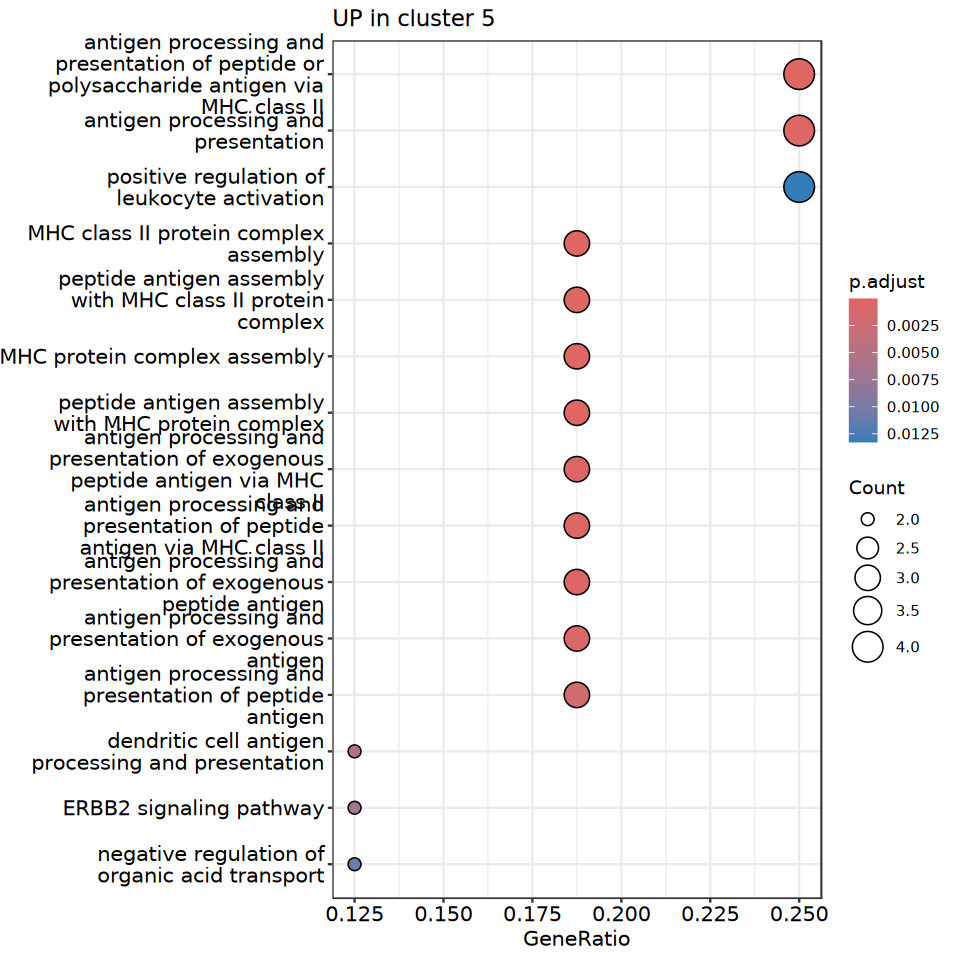

In [38]:
options(repr.plot.height = 8, repr.plot.width = 8)
if (!is.null(ego_up)   && nrow(as.data.frame(ego_up))   > 0) print(dotplot(ego_up,   showCategory = 15, title = "UP in cluster 5"))

preparing gene to GO mapping data...

preparing IC data...

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invaild edge matrix for <phylo>. A <tbl_df> is returned.

! # Invail

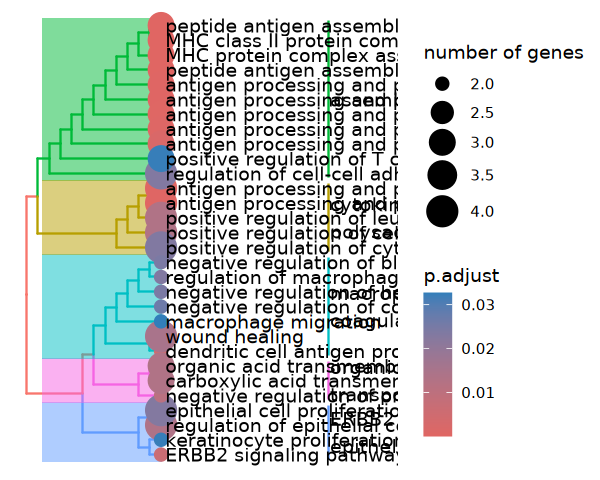

In [17]:
d <- godata('org.Hs.eg.db', ont="BP")
ego2 <- pairwise_termsim(ego_up, semData = d)
treeplot(ego2)